# Visualizing EEG signals and their frequency characteristics for sleep stage analysis

## Introduction
This notebook provides a polished template for visualizing EEG data using **MNE**, **Matplotlib**, and **Seaborn**.
It includes:
- Loading EEG data from EDF files.
- Visualizing raw EEG signals in the time domain.
- Plotting Power Spectral Density (PSD) for frequency analysis.
- Placeholders for annotations and summary insights.

**Goal:** Make EEG visualizations clear, informative, and aesthetically pleasing.

In [1]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

# Set Seaborn style for better aesthetics
sns.set(style="whitegrid", palette="muted")

# Configure Matplotlib for larger fonts and better readability
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

### Data

Load EEG data from an EDF file using MNE: https://physionet.org/content/sleep-edfx/1.0.0/#files-panel

In [2]:
edf_path = "sleepdata/SC4001E0-PSG.edf"
raw = mne.io.read_raw_edf(edf_path, preload=True)
hypnogram_file = "sleepdata/SC4001EC-Hypnogram.edf"
annot = mne.read_annotations(hypnogram_file)
raw.set_annotations(annot)

Extracting EDF parameters from C:\Users\onontsatsalg\Documents\Code\PersonalAI\sleepdata\SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_21988\2039223878.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_21988\2039223878.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_21988\2039223878.py:2: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_21988\2039223878.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [3]:
def visualize_channel(channel_name='EEG Fpz-Cz'):
    data, times = raw[channel_name]
    sfreq = raw.info['sfreq']  # Sampling frequency
    end_sample = int(60 * sfreq)
    data_60s = data[0][:end_sample]
    times_60s = times[:end_sample]
    
    # Create a line plot using seaborn
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 3))
    sns.lineplot(x=times_60s, y=data_60s)
    plt.title(f"Signal from Channel: {channel_name} (First 60 seconds)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.tight_layout()
    plt.show()

In [4]:
def visualize_frequency(channel_name):
    fs = raw.info['sfreq']
    segment = raw[channel_name][0][:600]  # First 60 seconds
    frequencies, psd = welch(segment, fs=fs, nperseg=1024)
    #frequencies, psd = welch(raw[channel_name][0], fs=fs, nperseg=1024)
    df = pd.DataFrame({'Frequency (Hz)': frequencies, 'Power': psd[0]})
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 3))
    ax = sns.lineplot(x='Frequency (Hz)', y='Power', data=df)
    plt.title(channel_name + ' Power Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (V^2/Hz)')
    plt.xlim(0, 50)  # Limit to 0–60 Hz for EEG
    ax.set_yscale('log')
    plt.show()

In [5]:
def visualize_annotation(raw_chan):
    raw_pick = raw.copy().pick([raw_chan])
    # --- Define time window (in seconds) ---
    start, stop = 20000, 60000
    sfreq = raw_pick.info['sfreq']
    start_samp = int(start * sfreq)
    stop_samp = int(stop * sfreq)
    
    # --- Extract EEG data ---
    data_seg, times_seg = raw_pick[:, start_samp:stop_samp]
    data_seg = data_seg[0] * 1e6  # convert V → µV
    
    # --- Define sleep stage colors ---
    stage_colors = {
        'Sleep stage W': '#FFD700',   # Yellow
        'Sleep stage 1': '#87CEFA',   # Light Blue
        'Sleep stage 2': '#4682B4',   # Medium Blue`a 
        'Sleep stage 3': '#00008B',   # Deep Blue
        'Sleep stage 4': '#00008B',   # Combine with N3
        'Sleep stage R': '#FF69B4',   # Pink/Red
    }
    
    fig, ax = plt.subplots(figsize=(15, 3))

    ax.plot(times_seg, data_seg, color='gray', linewidth=0.5, label=raw_chan)
    
    # --- Overlay sleep stages within the window ---
    for onset, duration, desc in zip(annot.onset, annot.duration, annot.description):
        if desc in stage_colors:
            if (onset + duration) > start and onset < stop:  # only show visible portion
                # Clip overlay to visible range
                left = max(onset, start)
                right = min(onset + duration, stop)
                ax.axvspan(left, right, color=stage_colors[desc], alpha=0.25)
    
    ax.set_xlim(start, stop)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("EEG Amplitude (µV)")
    ax.set_title(f'{raw_chan} with Sleep Stages (20,000–60,000 sec)')
    
    handles = [plt.Line2D([0], [0], color=color, lw=8, alpha=0.6)
                for color in stage_colors.values()]
    labels = [s.replace('Sleep stage ', '') for s in stage_colors.keys()]
    ax.legend(handles, labels, title="Sleep Stages", loc='upper right', frameon=True)
    sns.despine()
    plt.tight_layout()
    plt.show()


## Signal Visualization
Visualize raw channel signals for a selected time window. This helps to understand amplitude fluctuations.

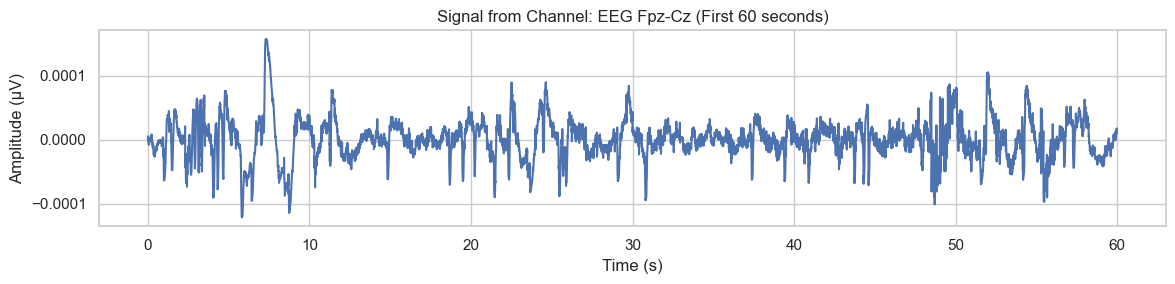

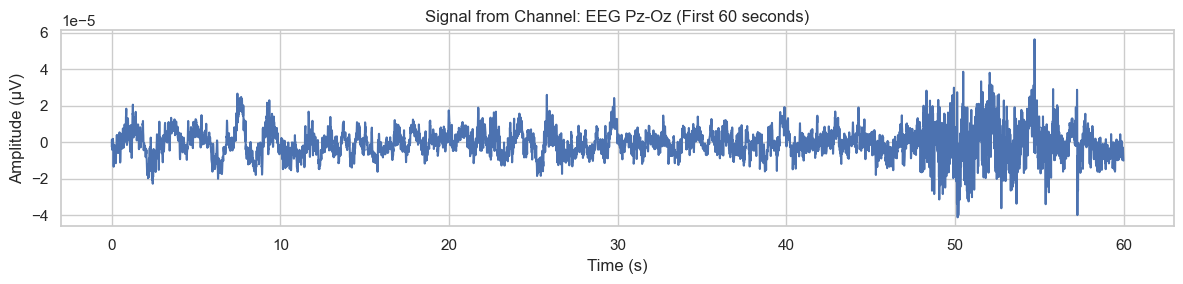

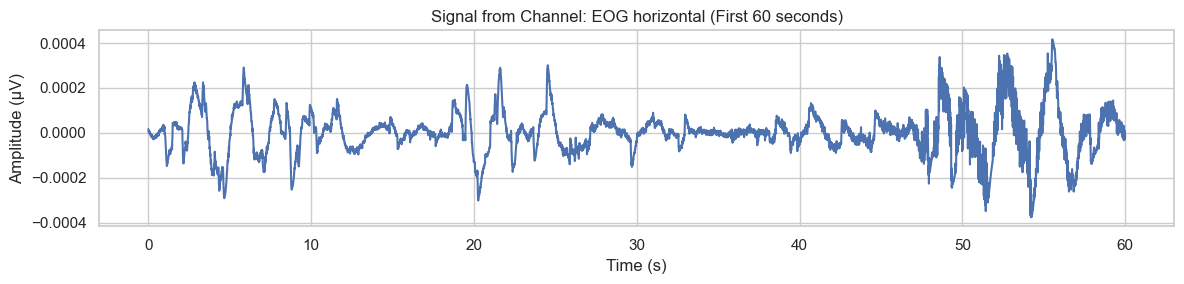

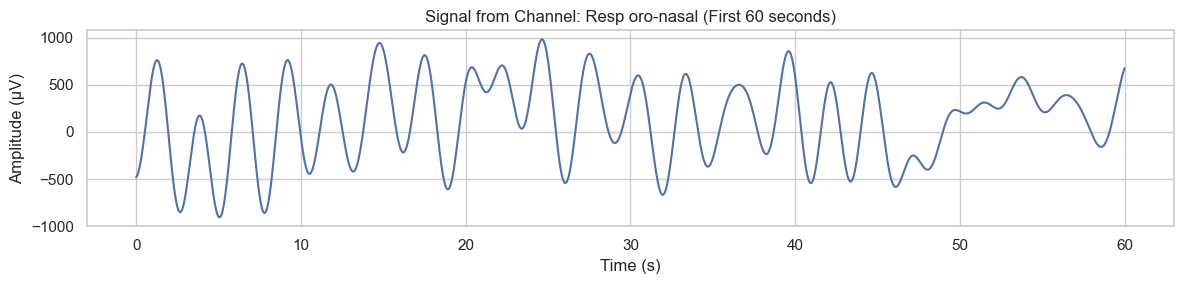

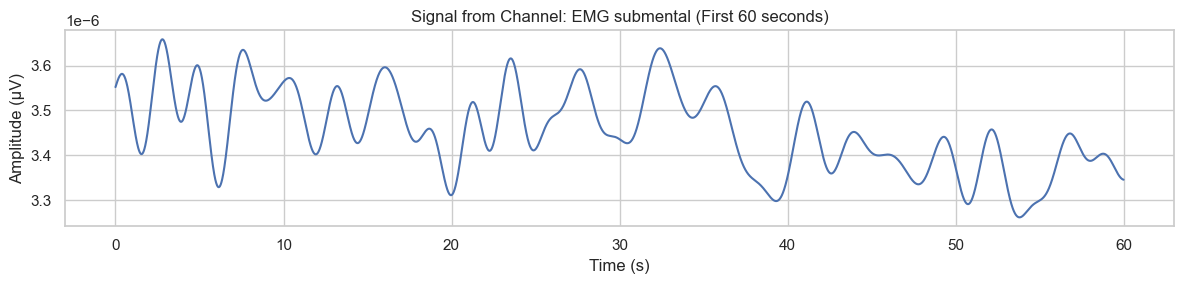

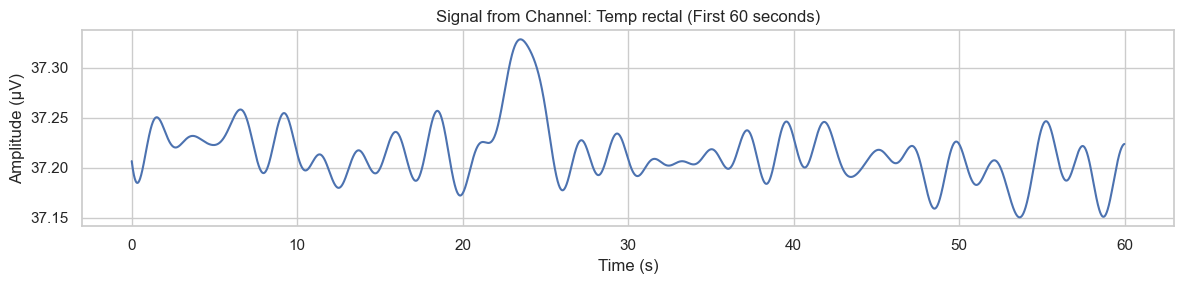

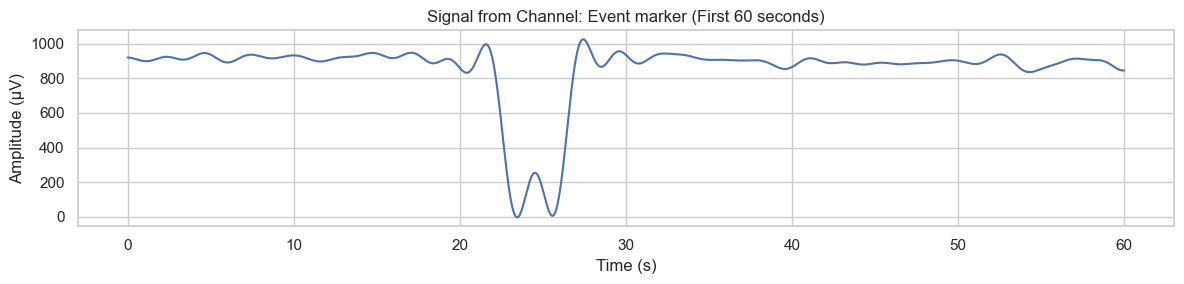

In [6]:
for channl in raw.ch_names:
    visualize_channel(channl)

## Frequency Analysis
Compute and visualize the Power Spectral Density (PSD) using Welch's method in log scale.
This highlights dominant frequency bands (delta, theta, alpha, beta).

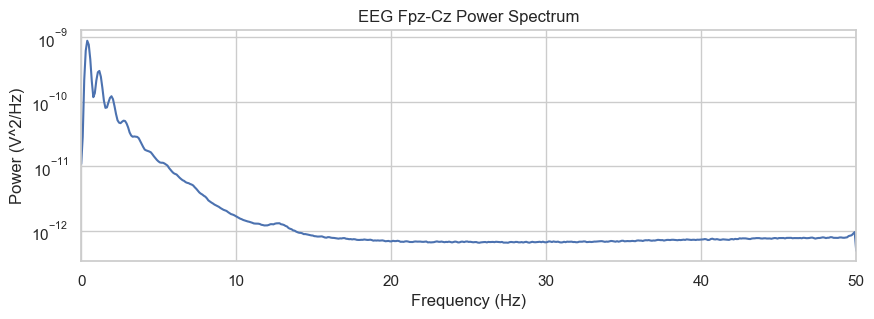

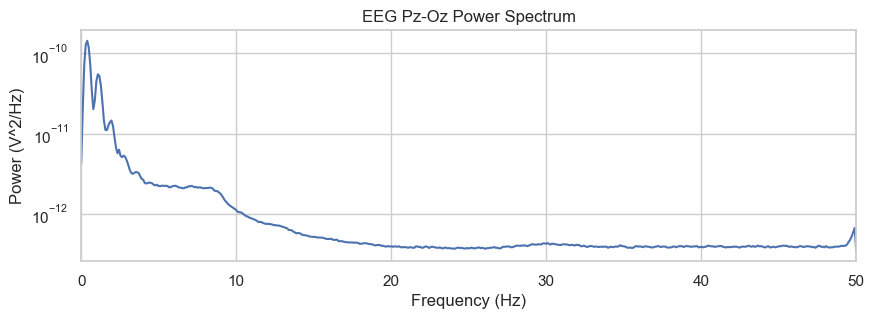

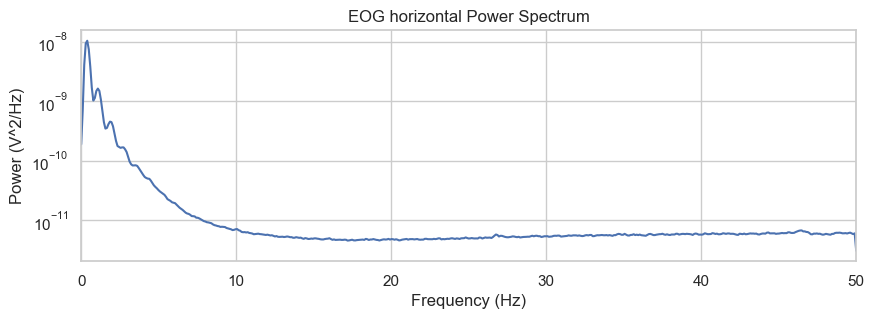

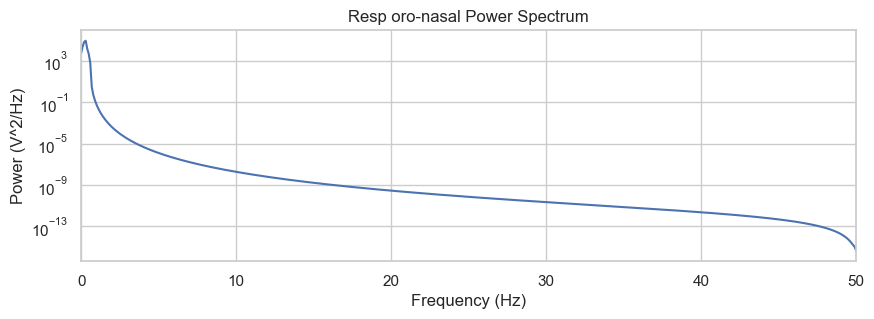

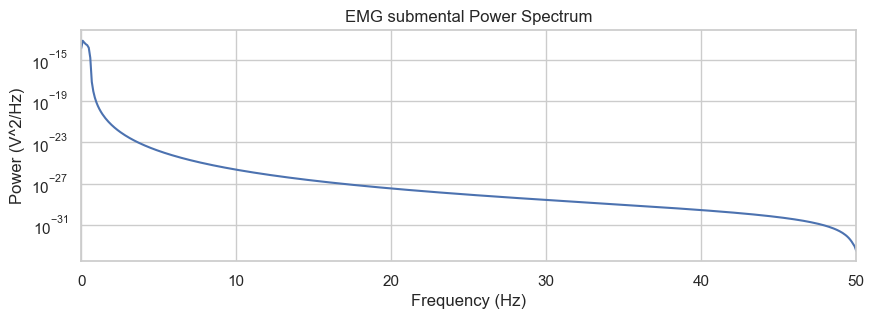

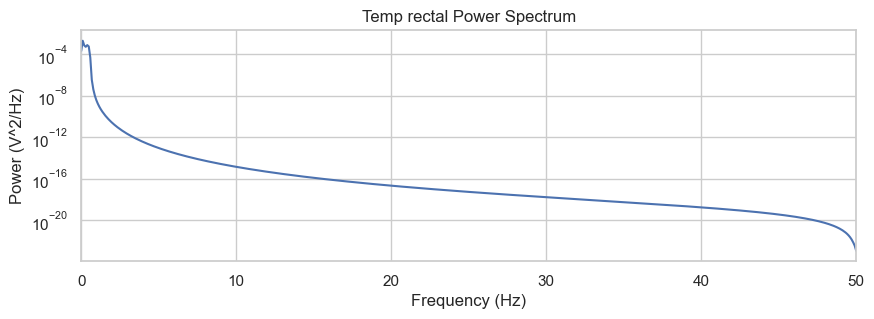

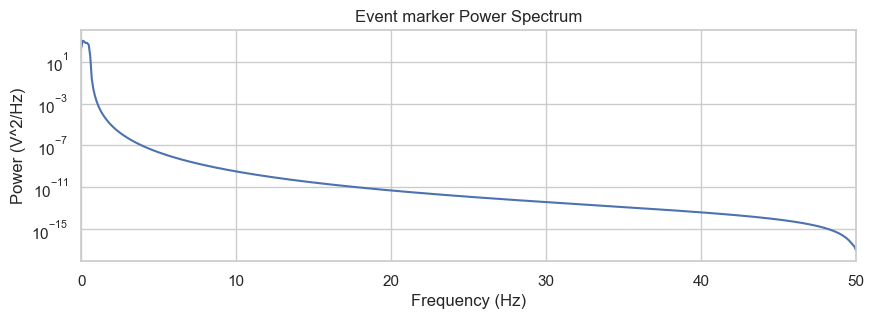

In [7]:
for channl in raw.ch_names:
    visualize_frequency(channl)

## Signal visualization with Annotations for the whole duration
This helps to understand change in data in longer duration.

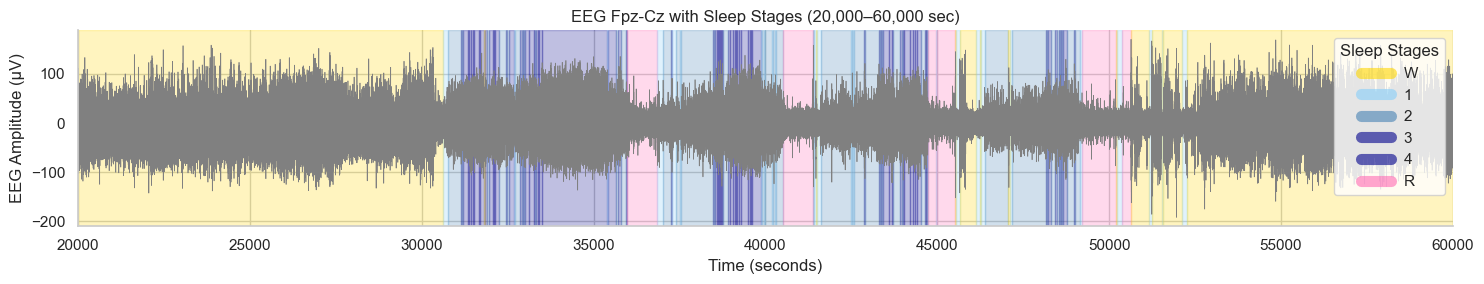

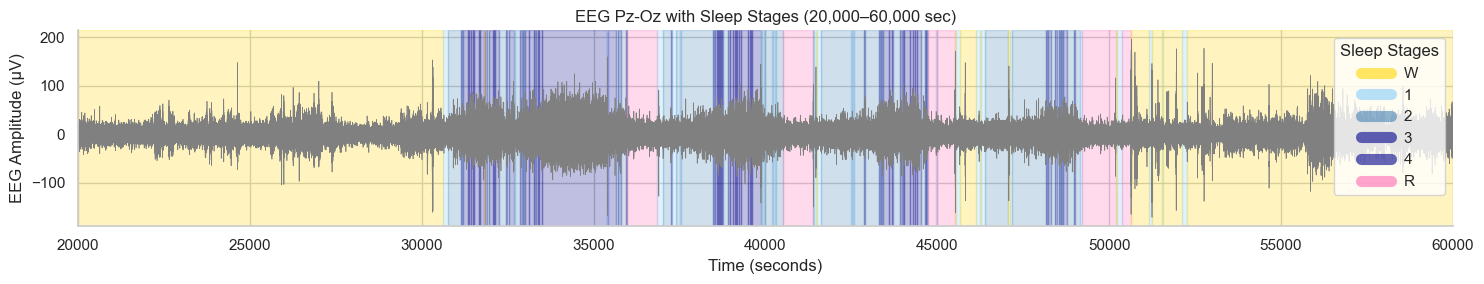

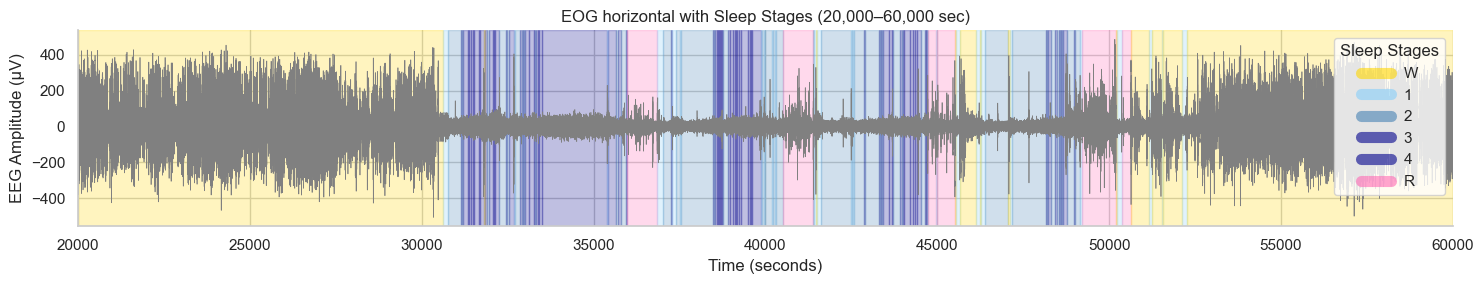

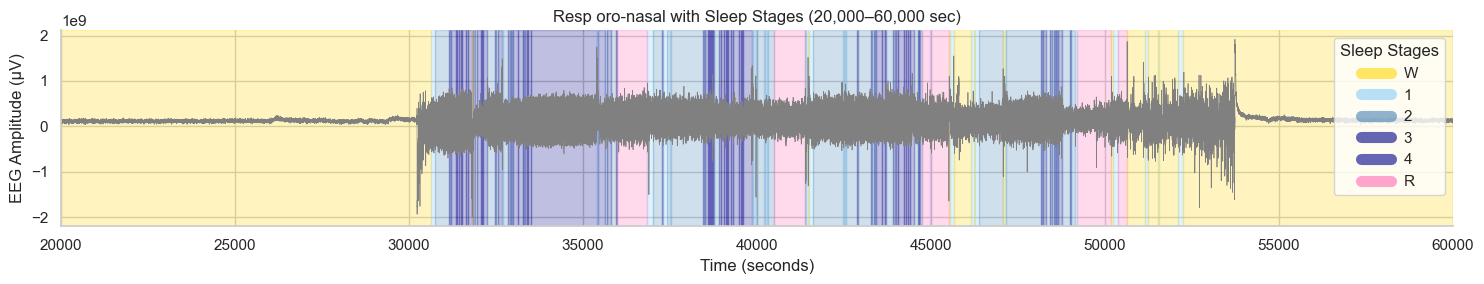

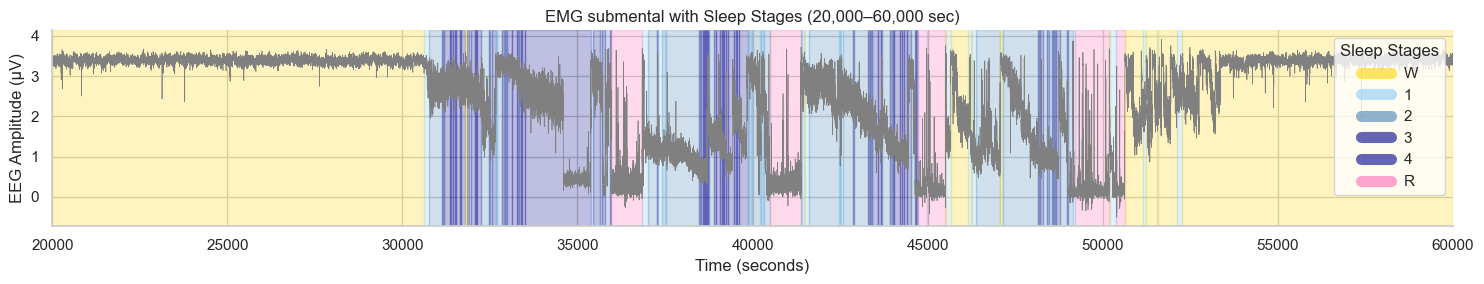

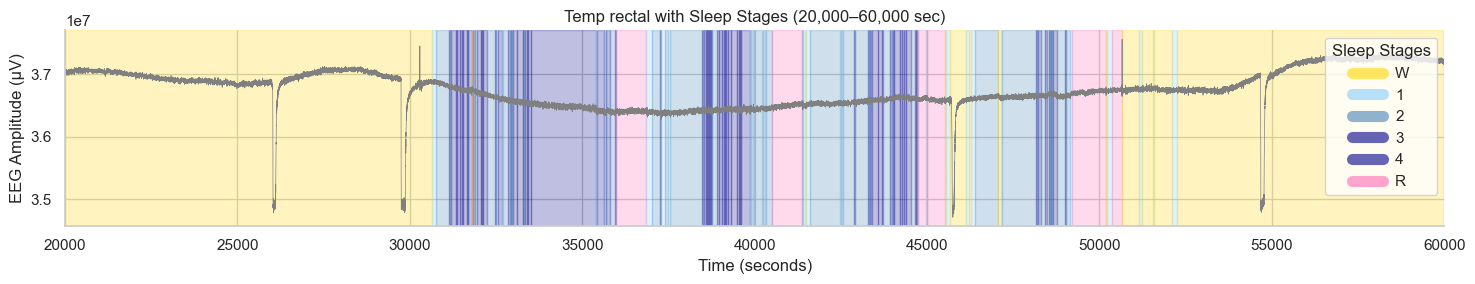

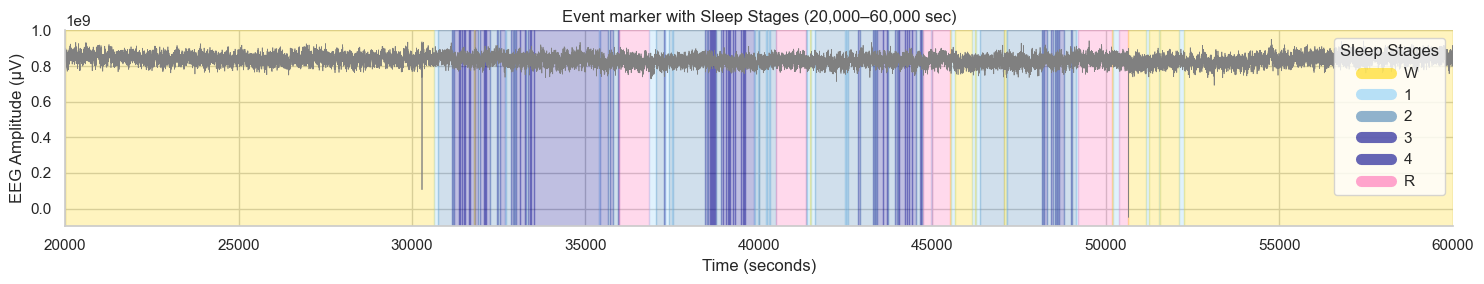

In [8]:
for channl in raw.ch_names:
    visualize_annotation(channl)

### Power Spectral Density (PSD) of EEG Channels

Extracting EDF parameters from C:\Users\onontsatsalg\Documents\Code\PersonalAI\sleepdata\SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_21988\580012291.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_21988\580012291.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_21988\580012291.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 20.480 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 20.480 (s)
Plotting power spectral density (dB=True).


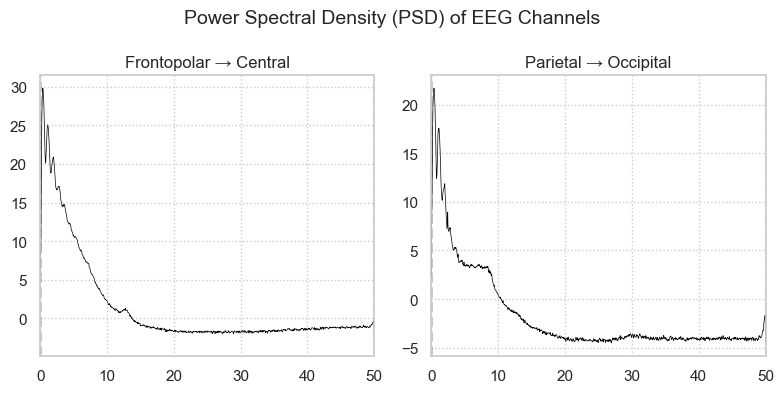

In [9]:
raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle(f'Power Spectral Density (PSD) of EEG Channels', fontsize=14)

# Plot PSD before filtering
raw.plot_psd(picks='EEG Fpz-Cz', ax=axes[0], average=True, show=False)
axes[0].set_title('Frontopolar → Central')

# Plot PSD after filtering
raw.plot_psd(picks='EEG Pz-Oz', ax=axes[1], average=True, show=False)
axes[1].set_title('Parietal → Occipital')

plt.tight_layout()
plt.show()

## Annotations and Summary Insights
- **Purpose:** With this notebook, raw data visualization is displayed in time-domain and in frequency-domain to get more understand on the data.
- **Sleep Stage:** On the visualizations, sleep stages are clearly defined by annotations. These sleep stages are annotated manually. Further in the project, we will try to automate this annotation.
- **Observations:** Summarize key findings from the visualizations.
    - There is signal change during sleep.
    - There is significant sleep stage and sleep cycles.